In [2]:
import os
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

In [3]:
import sklearn
import imblearn

print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

sklearn: 1.4.2
imblearn: 0.12.4


In [4]:
#Load dataset

df = pd.read_csv("dataset/synthetic_fraud_dataset.csv")
df.head()

,Transaction_ID,Time,Transaction_Date,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,Transaction_Type,Merchant_Category,...,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score,Is_Fraud
0,TXN00104242,16122600,2025-12-03 13:26:30,13,2,0,0,11027.61,Credit Card,Gaming,...,1,9,0,0,0,0,2149,3,23,0
1,TXN00199677,29893920,2026-05-11 22:48:30,22,0,0,0,1676.18,Bank Transfer,Crypto,...,1,2,0,0,0,0,1929,3,23,0
2,TXN00140200,14432760,2025-11-14 00:02:30,0,4,0,1,610.47,ATM,Insurance,...,1,11,0,1,0,0,2884,3,23,0
3,TXN00132815,1475760,2025-06-17 00:52:30,0,1,0,1,1262.61,Debit Card,Travel,...,2,12,0,0,0,1,763,1,23,0
4,TXN00408698,27676500,2026-04-16 06:51:30,6,3,0,0,1074.08,UPI,Food,...,1,1,1,0,0,0,1709,1,22,0


In [5]:
# Basic cleaning check

print("Shape: ", df.shape)
print("Missing values: ", df.isnull().sum().sum())
print("Duplicates: ", df.duplicated().sum())

Shape:  (500000, 24)
Missing values:  0
Duplicates:  0


In [6]:
# drop unnecessary columnsS

df = df.drop(columns=["Transaction_ID", "Transaction_Date"])
df.head()

,Time,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,Transaction_Type,Merchant_Category,Device_Type,City,...,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score,Is_Fraud
0,16122600,13,2,0,0,11027.61,Credit Card,Gaming,Android,Pune,...,1,9,0,0,0,0,2149,3,23,0
1,29893920,22,0,0,0,1676.18,Bank Transfer,Crypto,Laptop,Pune,...,1,2,0,0,0,0,1929,3,23,0
2,14432760,0,4,0,1,610.47,ATM,Insurance,iPhone,Ahmedabad,...,1,11,0,1,0,0,2884,3,23,0
3,1475760,0,1,0,1,1262.61,Debit Card,Travel,Laptop,Delhi,...,2,12,0,0,0,1,763,1,23,0
4,27676500,6,3,0,0,1074.08,UPI,Food,Tablet,Kolkata,...,1,1,1,0,0,0,1709,1,22,0


In [7]:
# separate features and target

x = df.drop("Is_Fraud", axis=1)
y = df["Is_Fraud"]

print("Features: ", x.shape)
print("Target: ", y.shape)

Features:  (500000, 21)
Target:  (500000,)


In [8]:
# Encode categorical columns

categorical_columns = [
    "Transaction_Type",
    "Merchant_Category",
    "Device_Type",
    "City",
    "Country"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

x.head()

,Time,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,Transaction_Type,Merchant_Category,Device_Type,City,...,International_Transaction,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score
0,16122600,13,2,0,0,11027.61,2,6,1,16,...,0,1,9,0,0,0,0,2149,3,23
1,29893920,22,0,0,0,1676.18,1,1,2,16,...,0,1,2,0,0,0,0,1929,3,23
2,14432760,0,4,0,1,610.47,0,8,4,1,...,0,1,11,0,1,0,0,2884,3,23
3,1475760,0,1,0,1,1262.61,3,11,2,6,...,0,2,12,0,0,0,1,763,1,23
4,27676500,6,3,0,0,1074.08,4,5,3,9,...,0,1,1,1,0,0,0,1709,1,22


In [9]:
# feature selection

selector = SelectKBest(score_func=f_classif, k=15)

x_selected = selector.fit_transform(x, y)

selected_features = x.columns[selector.get_support()].tolist()

selected_features

['Day_Of_Week',
 'Amount',
 'Merchant_Category',
 'City',
 'Country',
 'International_Transaction',
 'Failed_Login_Attempts',
 'Previous_Transactions_24H',
 'Unusual_Location',
 'VPN_Used',
 'Multiple_Cards_Used',
 'New_Device_Login',
 'Account_Age_Days',
 'Transaction_Velocity',
 'Risk_Score']

In [10]:
# Keep selected features

x = x[selected_features]

x.head()

,Day_Of_Week,Amount,Merchant_Category,City,Country,International_Transaction,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score
0,2,11027.61,6,16,3,0,1,9,0,0,0,0,2149,3,23
1,0,1676.18,1,16,3,0,1,2,0,0,0,0,1929,3,23
2,4,610.47,8,1,3,0,1,11,0,1,0,0,2884,3,23
3,1,1262.61,11,6,3,0,2,12,0,0,0,1,763,1,23
4,3,1074.08,5,9,3,0,1,1,1,0,0,0,1709,1,22


In [11]:
# train-test split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)
print("y_train: ", y_train.shape)
print("y_test ", y_test.shape)

x_train:  (400000, 15)
x_test:  (100000, 15)
y_train:  (400000,)
y_test  (100000,)


In [12]:
# feature scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaling completed")

Scaling completed


In [13]:
# Apply SMOTE
smote = SMOTE(random_state=42)

x_train_resampled, y_train_resampled = smote.fit_resample(
    x_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
Is_Fraud
0    384000
1     16000
Name: count, dtype: int64

After SMOTE:
Is_Fraud
0    384000
1    384000
Name: count, dtype: int64


In [14]:
# save preprocessed data

os.makedirs("processed_data", exist_ok=True)
os.makedirs("model_artifacts", exist_ok=True)

joblib.dump(x_train_resampled, "processed_data/x_train_resampled.pkl")
joblib.dump(x_test_scaled, "processed_data/x_test_scaled.pkl")
joblib.dump(y_train_resampled, "processed_data/y_train_resampled.pkl")
joblib.dump(y_test, "processed_data/y_test.pkl")

joblib.dump(scaler, "model_artifacts/scaler.pkl")
joblib.dump(label_encoders, "model_artifacts/label_encoders.pkl")
joblib.dump(selected_features, "model_artifacts/selected_features.pkl")

print("Preprocessing files saved successfully")

Preprocessing files saved successfully


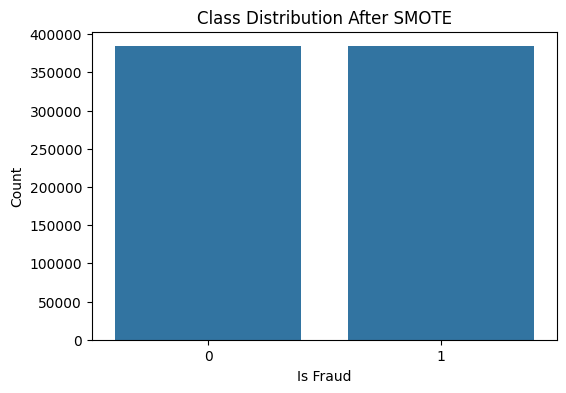

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_resampled)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Is Fraud")
plt.ylabel("Count")

plt.show()